In [45]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Loading the data set
View First Rows

In [47]:
df = pd.read_csv("/kaggle/input/datasets/ndarvind/phiusiil-phishing-url-dataset/PhiUSIIL_Phishing_URL_Dataset.csv")
df.head()

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


# PART 2 — Statistic Analysis

# Check Dataset Shape

In [48]:
df.shape

(235795, 55)

The dataset contains 235,795 samples and 54 features, indicating a large dataset suitable for machine learning analysis.

# Dataset Information

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235795 entries, 0 to 235794
Data columns (total 55 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   URL                         235795 non-null  object 
 1   URLLength                   235795 non-null  int64  
 2   Domain                      235795 non-null  object 
 3   DomainLength                235795 non-null  int64  
 4   IsDomainIP                  235795 non-null  int64  
 5   TLD                         235795 non-null  object 
 6   URLSimilarityIndex          235795 non-null  float64
 7   CharContinuationRate        235795 non-null  float64
 8   TLDLegitimateProb           235795 non-null  float64
 9   URLCharProb                 235795 non-null  float64
 10  TLDLength                   235795 non-null  int64  
 11  NoOfSubDomain               235795 non-null  int64  
 12  HasObfuscation              235795 non-null  int64  
 13  NoOfObfuscated

# Check Column Names

In [50]:
df.columns

Index(['URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP', 'TLD',
       'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb',
       'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation',
       'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL',
       'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL',
       'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL',
       'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS',
       'LineOfCode', 'LargestLineLength', 'HasTitle', 'Title',
       'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots',
       'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription',
       'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet',
       'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay',
       'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS',
       'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'labe

# Statistical Summary

In [51]:
df.describe()

,URLLength,DomainLength,IsDomainIP,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,TLDLength,NoOfSubDomain,HasObfuscation,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
count,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,...,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000,235795.000000
mean,34.573095,21.470396,0.002706,78.430778,0.845508,0.260423,0.055747,2.764456,1.164758,0.002057,...,0.237007,0.023474,0.486775,26.075689,6.333111,10.522305,65.071113,2.377629,49.262516,0.571895
std,41.314153,9.150793,0.051946,28.976055,0.216632,0.251628,0.010587,0.599739,0.600969,0.045306,...,0.425247,0.151403,0.499826,79.411815,74.866296,22.312192,176.687539,17.641097,161.027430,0.494805
min,13.000000,4.000000,0.000000,0.155574,0.000000,0.000000,0.001083,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,16.000000,0.000000,57.024793,0.680000,0.005977,0.050747,2.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,27.000000,20.000000,0.000000,100.000000,1.000000,0.079963,0.057970,3.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,8.000000,2.000000,6.000000,12.000000,0.000000,10.000000,1.000000
75%,34.000000,24.000000,0.000000,100.000000,1.000000,0.522907,0.062875,3.000000,1.000000,0.000000,...,0.000000,0.000000,1.000000,29.000000,8.000000,15.000000,88.000000,1.000000,57.000000,1.000000
max,6097.000000,110.000000,1.000000,100.000000,1.000000,0.522907,0.090824,13.000000,10.000000,1.000000,...,1.000000,1.000000,1.000000,8956.000000,35820.000000,6957.000000,27397.000000,4887.000000,27516.000000,1.000000


# Check Missing Values

In [52]:
df.isnull().sum()

URL                           0
URLLength                     0
Domain                        0
DomainLength                  0
IsDomainIP                    0
TLD                           0
URLSimilarityIndex            0
CharContinuationRate          0
TLDLegitimateProb             0
URLCharProb                   0
TLDLength                     0
NoOfSubDomain                 0
HasObfuscation                0
NoOfObfuscatedChar            0
ObfuscationRatio              0
NoOfLettersInURL              0
LetterRatioInURL              0
NoOfDegitsInURL               0
DegitRatioInURL               0
NoOfEqualsInURL               0
NoOfQMarkInURL                0
NoOfAmpersandInURL            0
NoOfOtherSpecialCharsInURL    0
SpacialCharRatioInURL         0
IsHTTPS                       0
LineOfCode                    0
LargestLineLength             0
HasTitle                      0
Title                         0
DomainTitleMatchScore         0
URLTitleMatchScore            0
HasFavic

The dataset does not contain missing values which simplifies preprocessing.

# Check Class Distribution

In [53]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

# Check duplicate rows

In [54]:
df.duplicated().sum()

np.int64(0)

# PART 2 — Visual Analysis

# Class Distribution (countplot)

**This shows how many phishing vs legitimate URLs exist.**

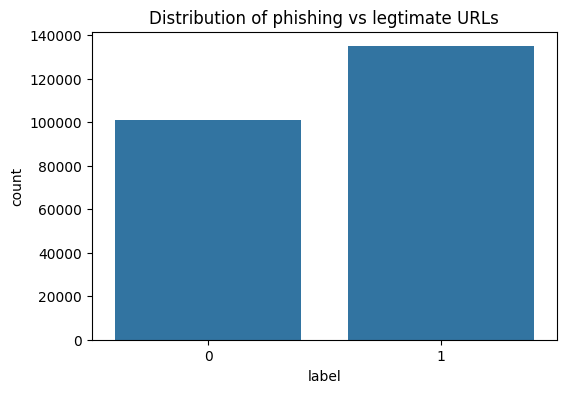

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x="label",data=df)
plt.title("Distribution of phishing vs legtimate URLs")
plt.show()

The plot shows the distribution of phishing and legitimate URLs in the dataset.

# URL Length Distribution (histplot)

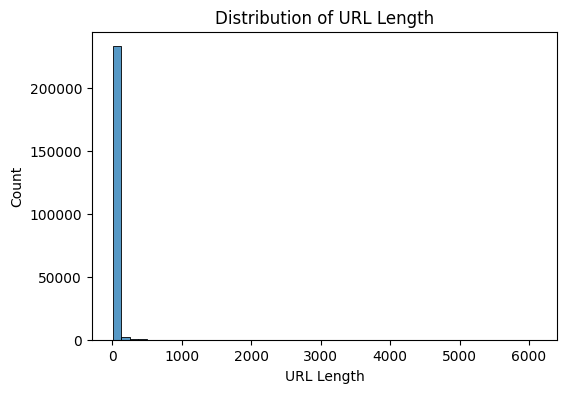

In [56]:
plt.figure(figsize=(6,4))
sns.histplot(df["URLLength"], bins=50)
plt.title("Distribution of URL Length")
plt.xlabel("URL Length")
plt.show()

# Domain Length Boxplot (Outlier Detection)

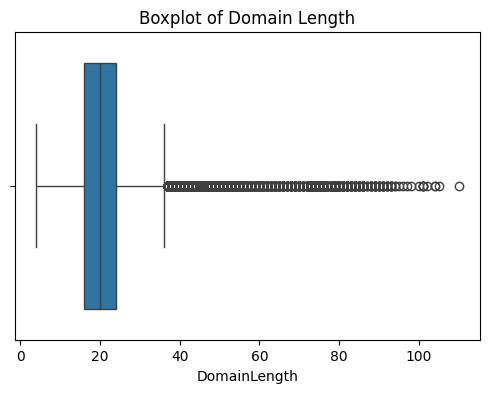

In [57]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["DomainLength"])
plt.title("Boxplot of Domain Length")
plt.show()

The boxplot reveals the presence of outliers, indicating some domains have unusually long names which may be characteristic of phishing URLs.

# URL Length vs Domain Length (Scatter Plot)

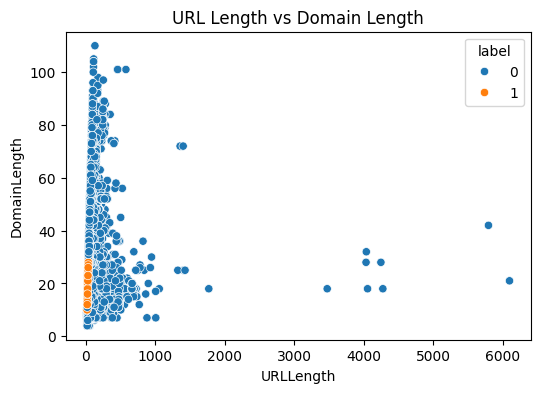

In [58]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="URLLength", y="DomainLength", hue="label", data=df)
plt.title("URL Length vs Domain Length")
plt.show()

The scatter plot shows how URL length relates to domain length. Some phishing URLs appear to have longer URL structures compared to legitimate ones

# Feature Correlation Heatmap

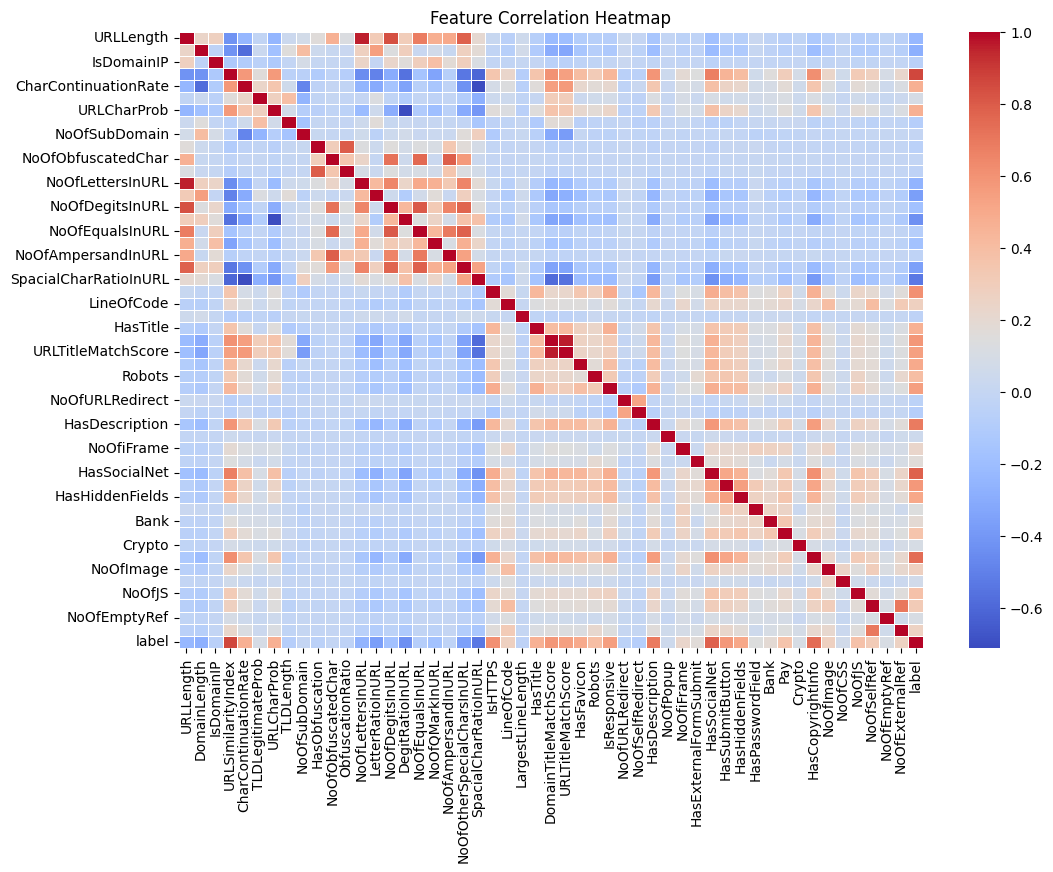

In [59]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(), cmap="coolwarm", linewidths=0.7)

plt.title("Feature Correlation Heatmap")

plt.show()

The heatmap shows correlations among features. Highly correlated features may indicate redundancy and can be considered during preprocessing.

# Special Character Ratio Distribution

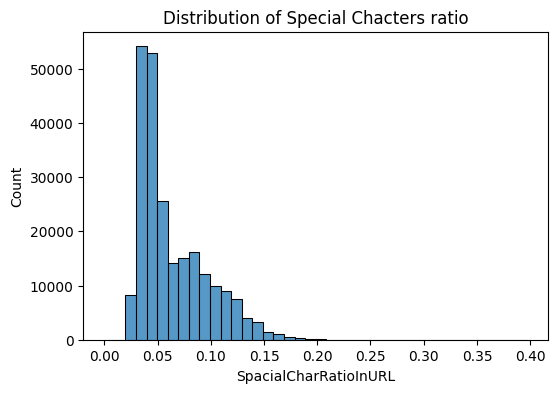

In [60]:
plt.figure(figsize=(6,4))
sns.histplot(df["SpacialCharRatioInURL"],bins=40)
plt.title("Distribution of Special Chacters ratio")
plt.show()

Higher ratios of special characters may indicate suspicious URLs commonly used in phishing attacks

# Histogram of All numeric Features

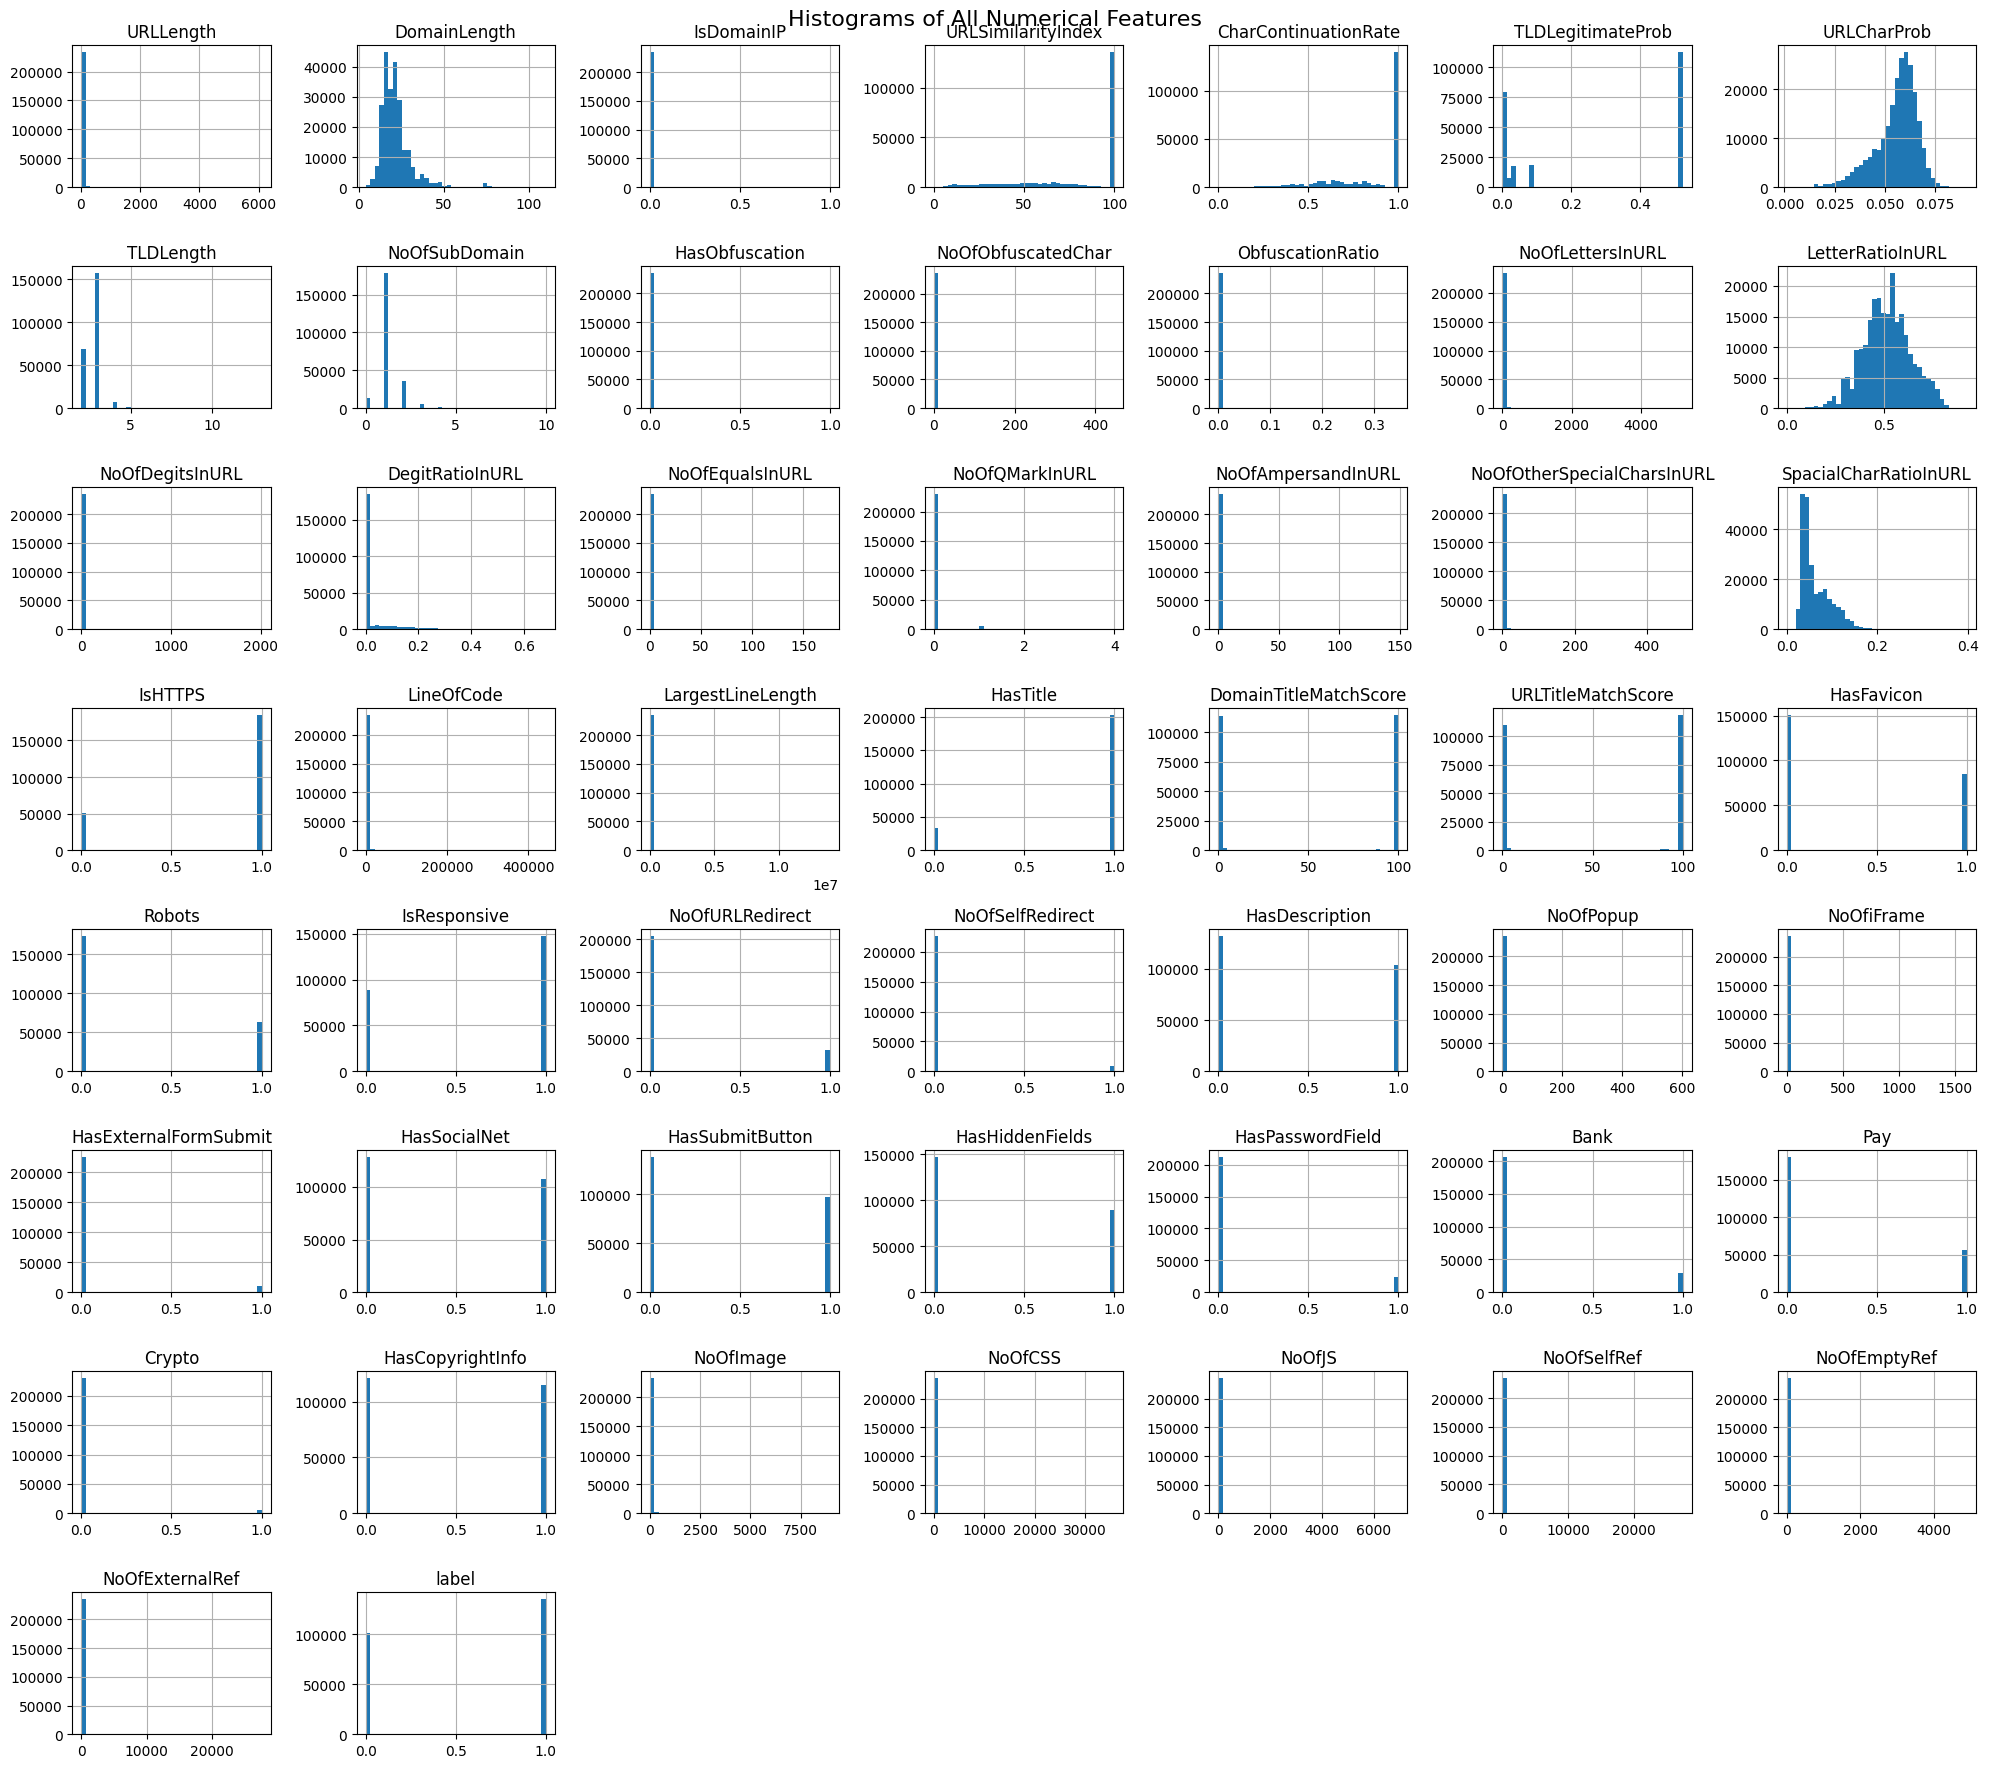

In [63]:
num_cols = df.select_dtypes(include=['int64','float64'])

# Plot histograms for all numeric features
num_cols.hist(figsize=(20,18), bins=40)

plt.suptitle("Histograms of All Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Automatically selects all numeric features

Creates histograms for each column

Displays them together in a grid

# Boxplot for All Numerical Columns

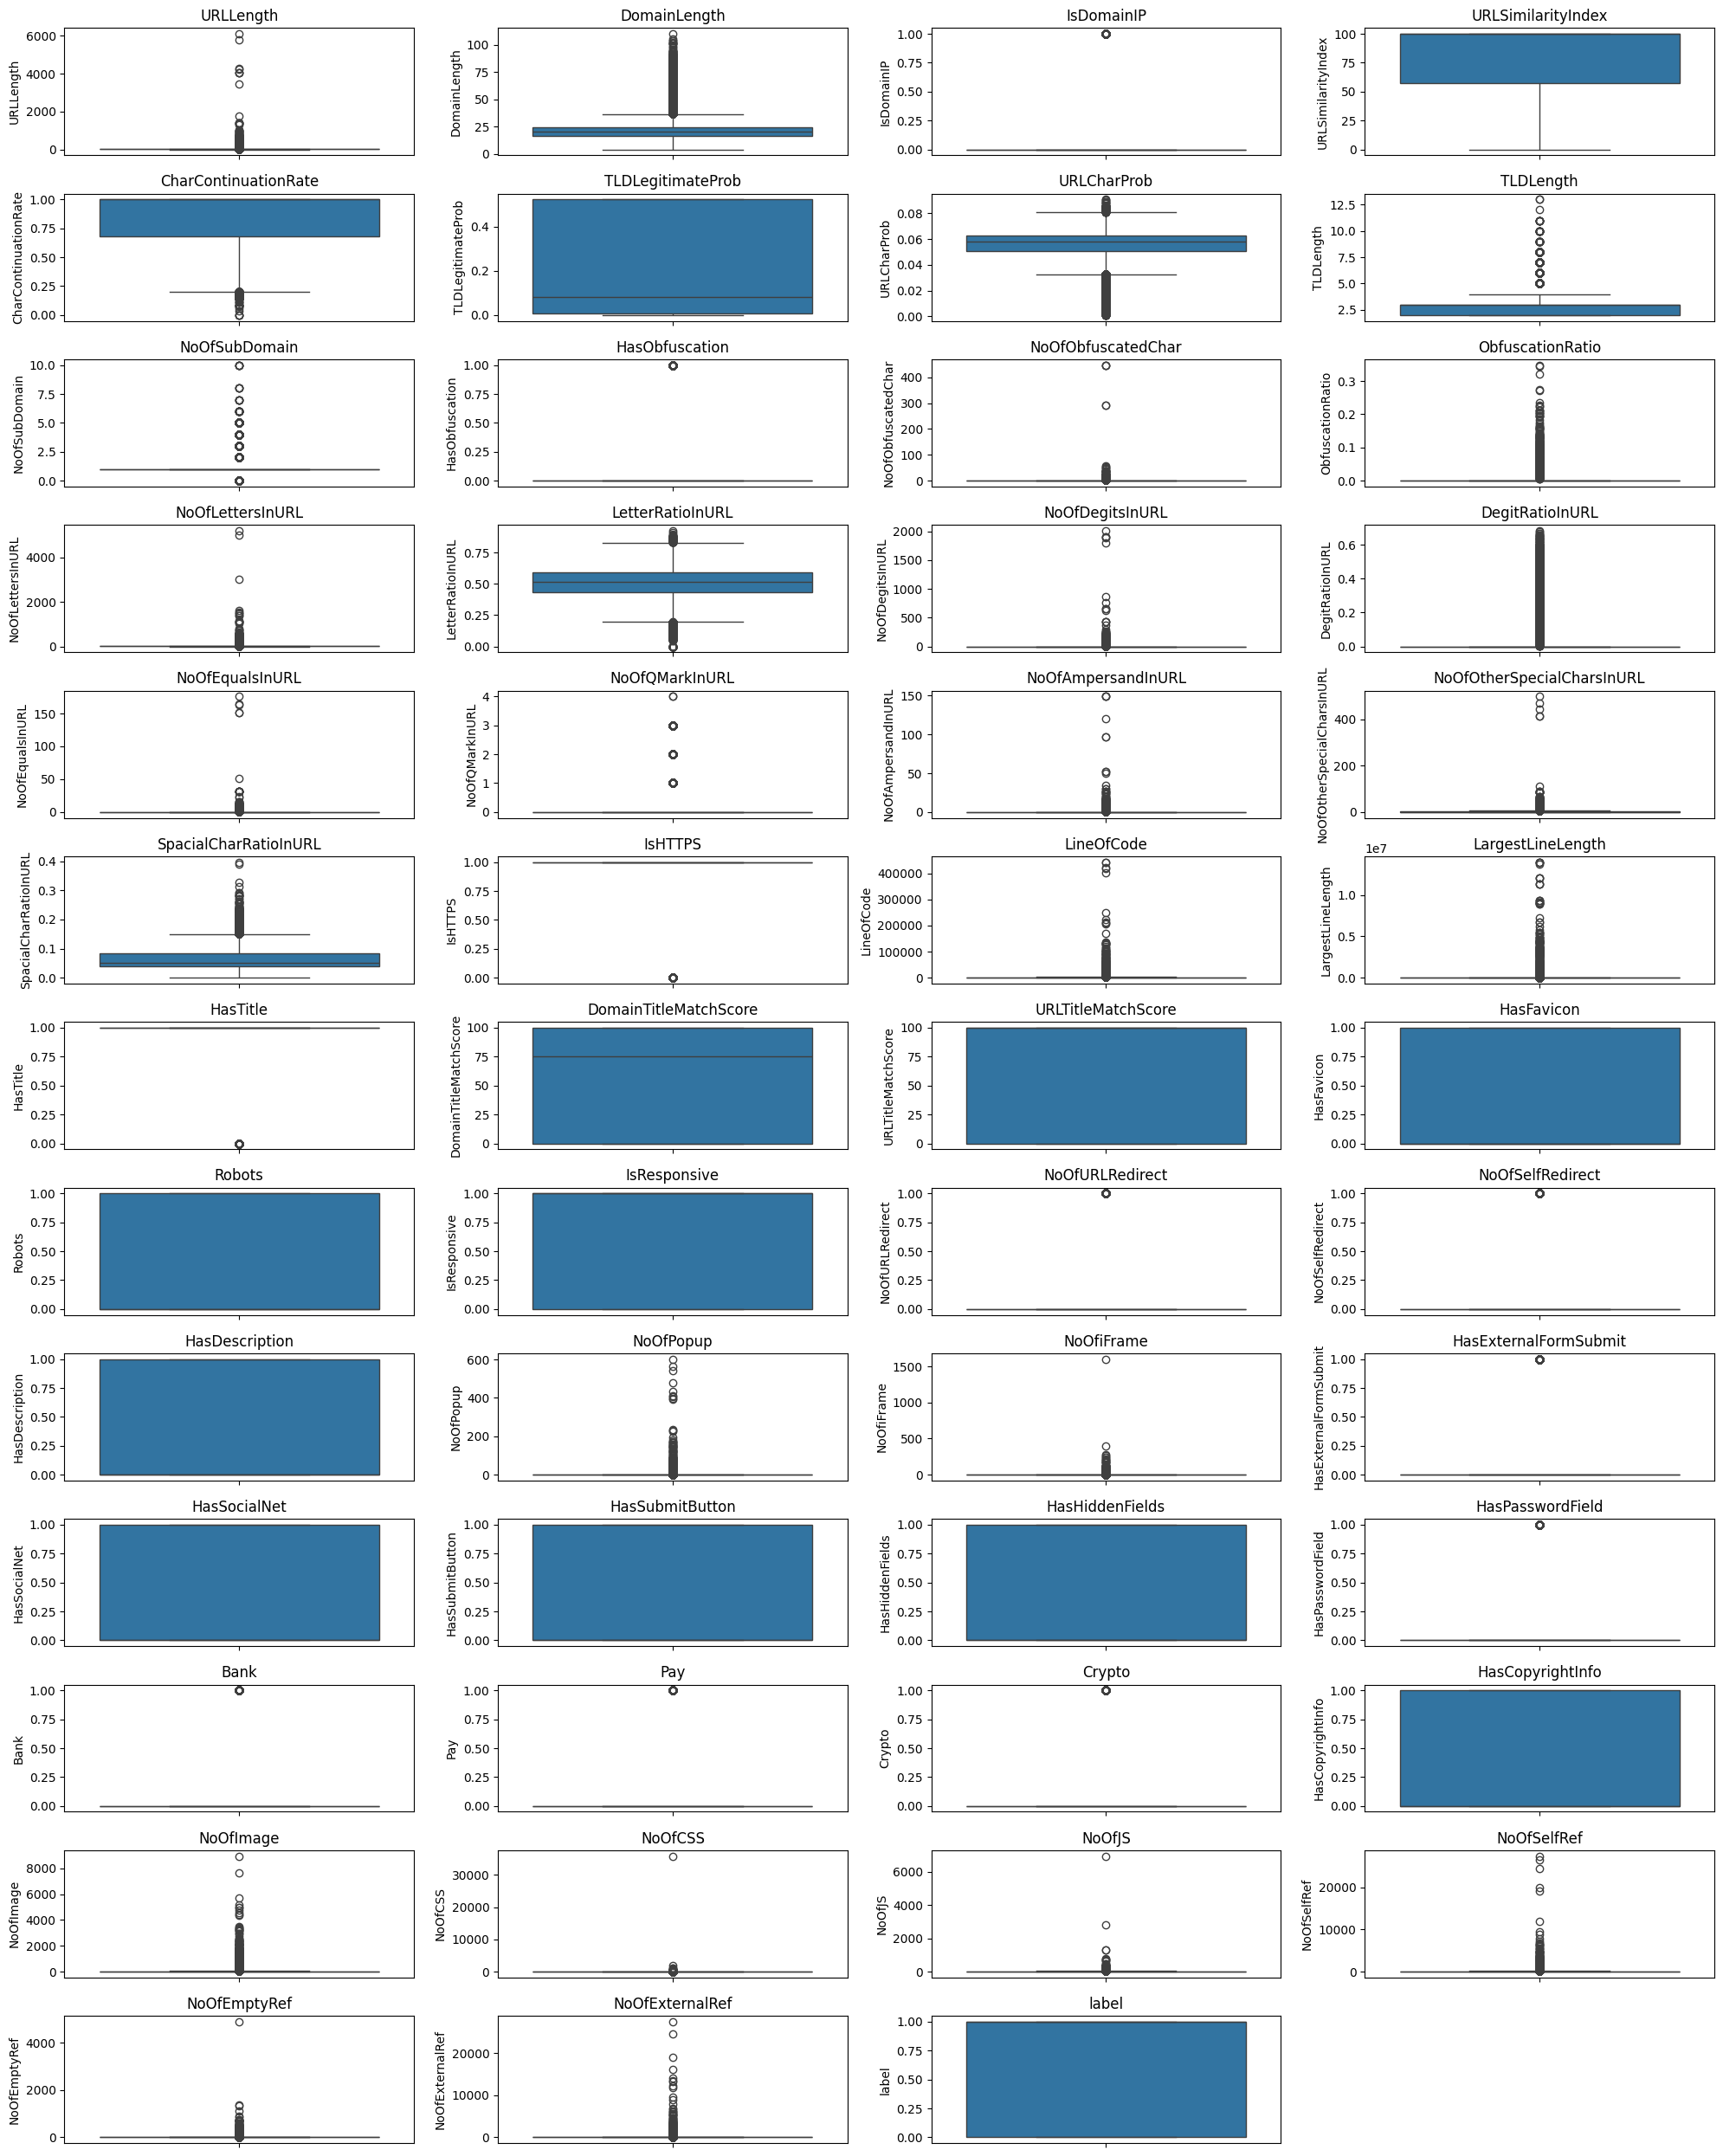

In [62]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
plt.figure(figsize=(20,25))

# Loop through columns
for i, col in enumerate(num_cols):
    plt.subplot((len(num_cols)//4)+1, 4, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Preprocessing
 # Drop irrelevant features

In [66]:

# Dropping raw text columns as they are too unique for standard ML models to learn from easily
df_clean = df.drop(columns=['URL', 'Domain', 'Title'])

Dropped URL, Domain, and Title because they are highly unique string identifiers that do not provide generalizable numerical patterns for the model.

# Save the Dataset

In [ ]:

df_clean.to_csv('preprocessed_phishing_dataset.csv', index=False)


# Phase 3
# Feature Importance


# Method 1: Correlation

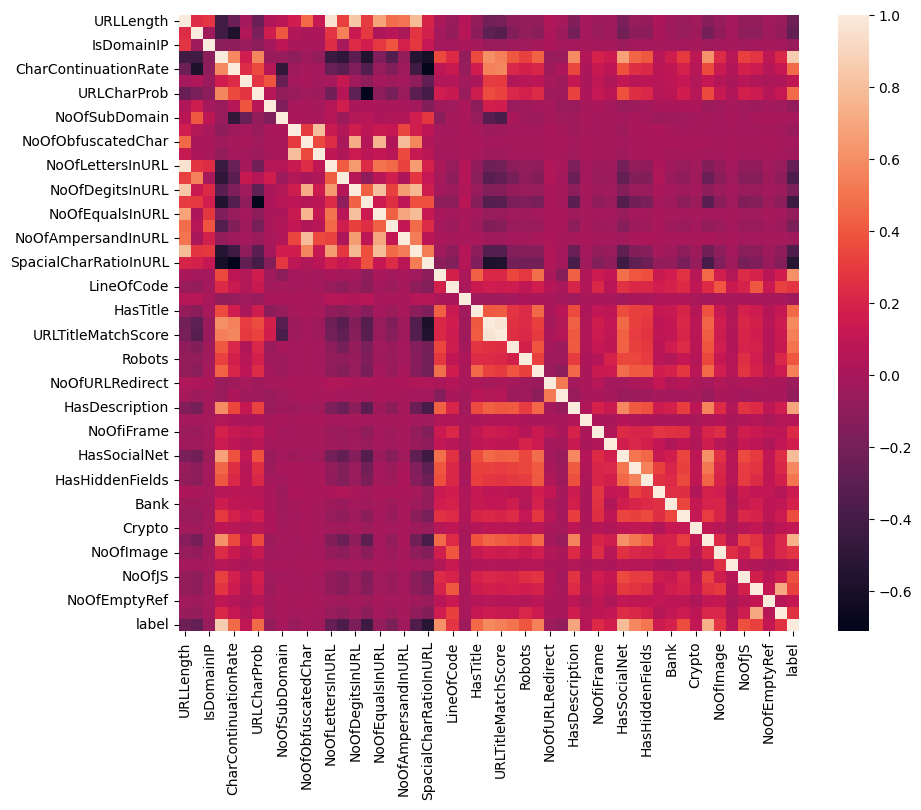

In [67]:
df = df.drop(columns=df.select_dtypes(include="object").columns)

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr)
plt.show()

# Method 2: Random Forest

In [68]:
X = df.drop("label", axis=1)
y = df["label"]

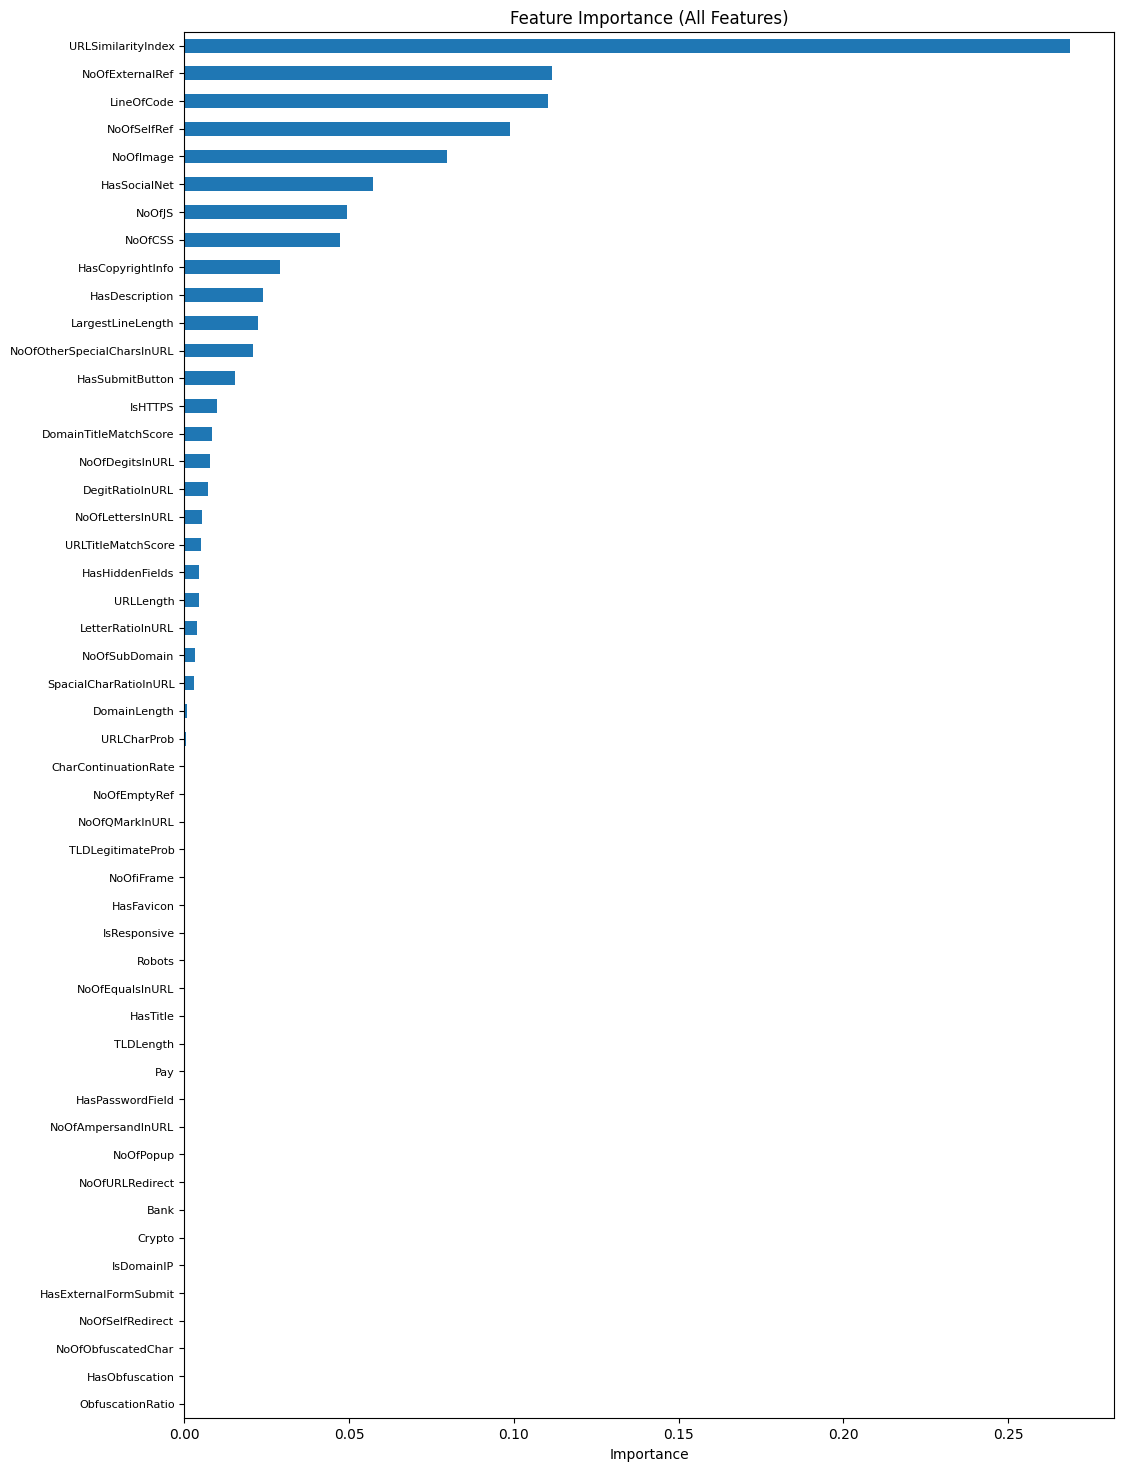

In [69]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values()

plt.figure(figsize=(12,18))   # very tall figure

importance.plot(kind="barh")

plt.yticks(fontsize=8)   # smaller text
plt.xlabel("Importance")
plt.title("Feature Importance (All Features)")

plt.show()

# Method 3: Logistic Regression

In [70]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# remove text columns
df2 = df.drop(columns=df.select_dtypes(include="object").columns)

X = df2.drop("label", axis=1)
y = df2["label"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(max_iter=5000)

model.fit(X_scaled, y)

LogisticRegression(max_iter=5000)

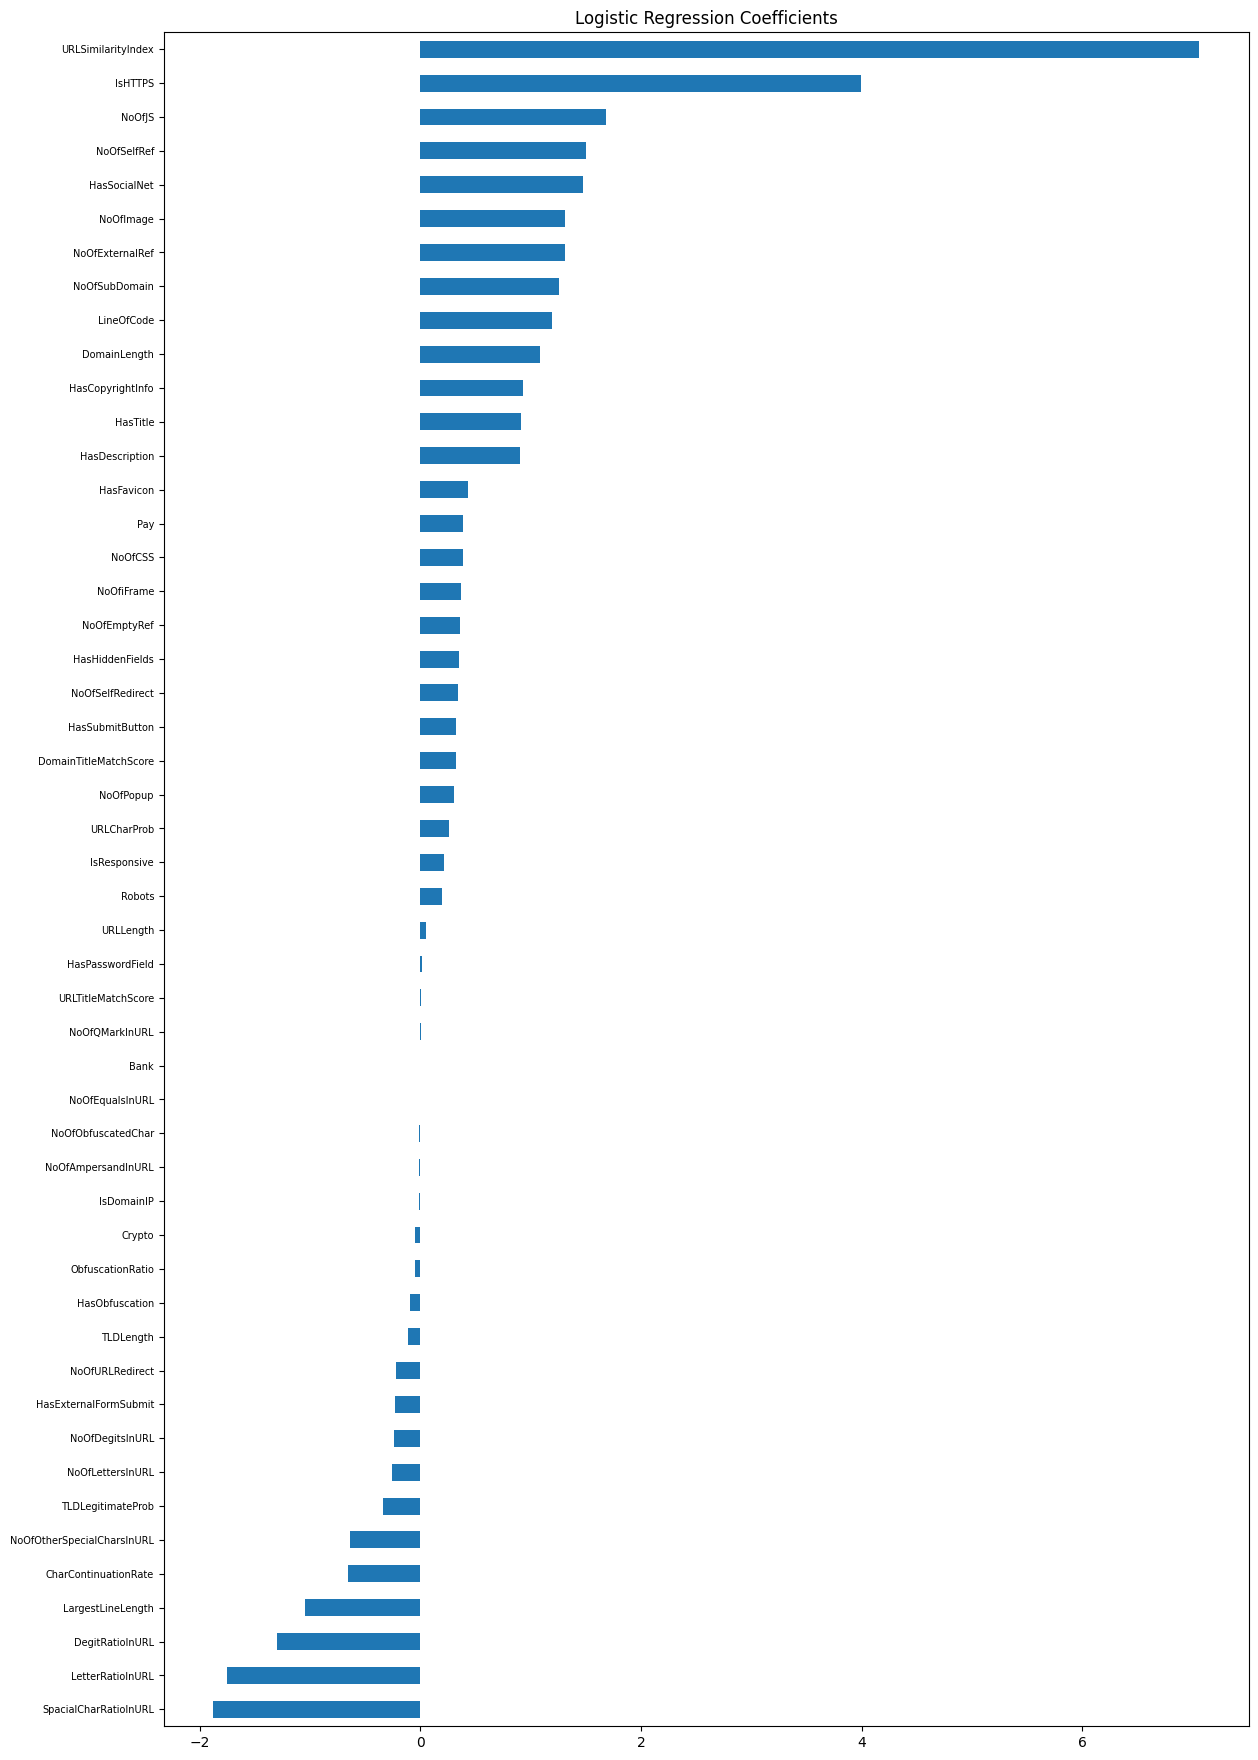

In [71]:
coef = pd.Series(
    model.coef_[0],
    index=X.columns
)

coef = coef.sort_values()

plt.figure(figsize=(14,22))

coef.plot(kind="barh")

plt.yticks(fontsize=7)

plt.title("Logistic Regression Coefficients")

plt.show()

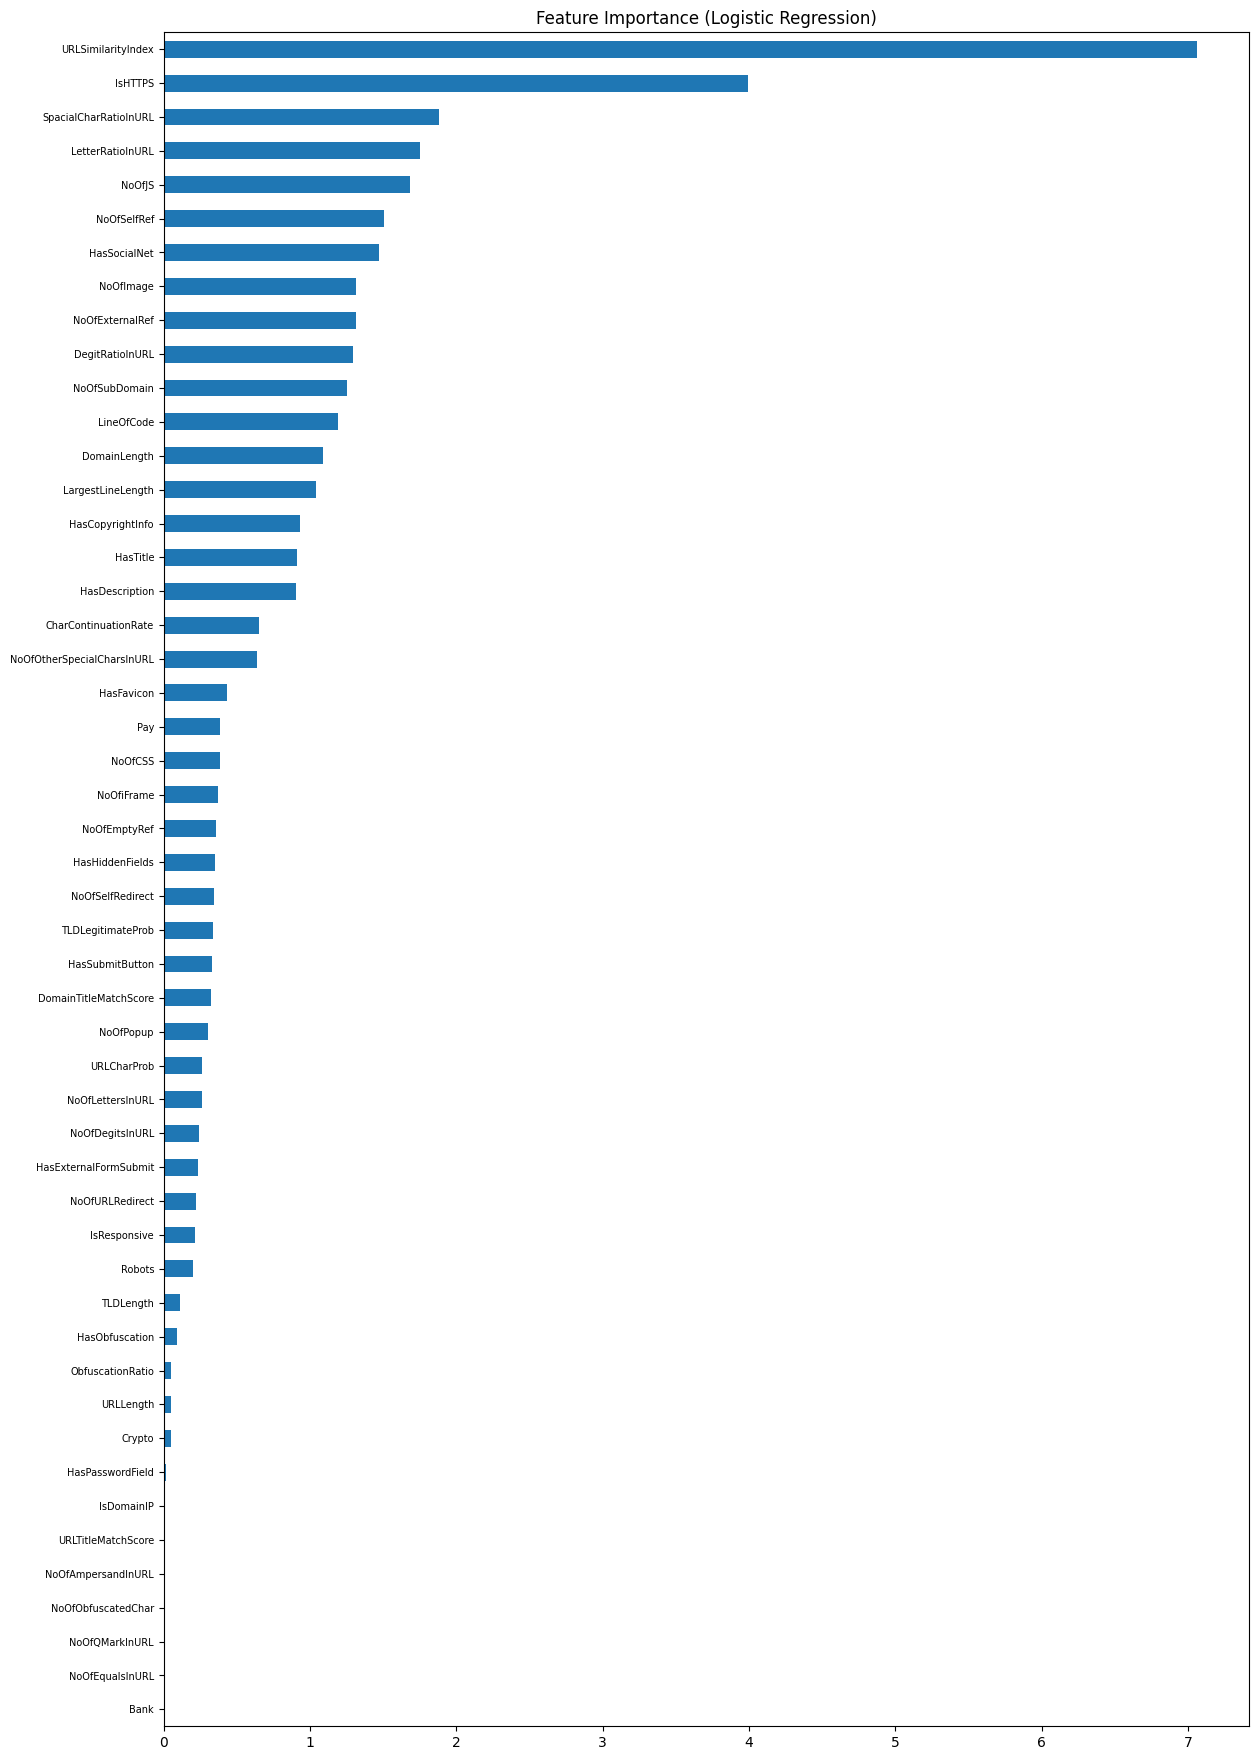

In [72]:
coef = pd.Series(
    abs(model.coef_[0]),
    index=X.columns
)

coef = coef.sort_values()

plt.figure(figsize=(14,22))

coef.plot(kind="barh")

plt.yticks(fontsize=7)

plt.title("Feature Importance (Logistic Regression)")

plt.show()

# Method 4: SHAP

In [78]:
import shap
df2 = df.drop(columns=df.select_dtypes(include="object").columns)

X = df2.drop("label", axis=1)
y = df2["label"]


In [ ]:
import shap

from sklearn.ensemble import RandomForestClassifier

df2 = df.drop(columns=df.select_dtypes(include="object").columns)

X = df2.drop("label", axis=1)
y = df2["label"]

model = RandomForestClassifier()
model.fit(X, y)

X_sample = X.sample(300, random_state=42)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(
    shap_values,
    X_sample,
    max_display=20
)



# Method 5: LIME

In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X.values,
    feature_names=X.columns,
    class_names=["Legit","Phishing"]
)

exp = explainer.explain_instance(
    X.values[0],
    model.predict_proba
)

exp.show_in_notebook()

# Create New Features

In [ ]:
# ===============================
# STEP 7 — Feature Engineering
# ===============================

# Suspicious score
df["Suspicious_Score"] = (
    df["IsDomainIP"] +
    df["HasObfuscation"] +
    df["HasHiddenFields"] +
    df["HasPasswordField"]
)


# URL Complexity
df["URL_Complexity"] = (
    df["URLLength"] *
    df["NoOfSubDomain"]
)


# Special Character Risk
df["SpecialChar_Risk"] = (
    df["NoOfOtherSpecialCharsInURL"] +
    df["SpacialCharRatioInURL"]
)


# Security Risk
df["Security_Risk"] = (
    (1 - df["IsHTTPS"]) +
    df["HasExternalFormSubmit"] +
    df["NoOfURLRedirect"]
)


# Content Risk
df["Content_Risk"] = (
    df["NoOfPopup"] +
    df["NoOfiFrame"] +
    df["NoOfExternalRef"]
)


# Financial keyword risk
df["Finance_Risk"] = (
    df["Bank"] +
    df["Pay"] +
    df["Crypto"]
)


# Script complexity
df["Script_Complexity"] = (
    df["NoOfJS"] +
    df["NoOfCSS"] +
    df["NoOfImage"]
)


# Check new columns
print("New columns added:")
print(df.columns)

New features were created by combining multiple related attributes such as URL length,
subdomains, HTTPS usage, popup count, script count, and financial keywords.

These engineered features help the model better identify phishing patterns
and improve prediction performance.

# Check with LightGBM

In [81]:
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Remove text columns
df2 = df.drop(columns=df.select_dtypes(include="object").columns)

# Target
X = df2.drop("label", axis=1)
y = df2["label"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Model
model = LGBMClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

[LightGBM] [Info] Number of positive: 107815, number of negative: 80821
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042536 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4880
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571550 -> initscore=0.288180
[LightGBM] [Info] Start training from score 0.288180
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

LightGBM model achieved an accuracy of 1.0 on the test set.
This extremely high accuracy indicates that the dataset contains highly informative features, making phishing detection relatively easy for the model.
However, such perfect accuracy may also suggest overfitting or the presence of highly correlated or leakage features.
The warnings during training indicate that no further beneficial splits were found, which confirms that the model quickly learned the patterns in the data.

LightGBM used to evaluate new features.

In [82]:
#Instead of only accuracy, add more metrics
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, pred))

print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159

[[20124     0]
 [    0 27035]]


In [83]:
#Check if overfitting
train_pred = model.predict(X_train)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy:", accuracy_score(y_test, pred))

Train Accuracy: 1.0
Test Accuracy: 1.0


# Drop Less Important Features

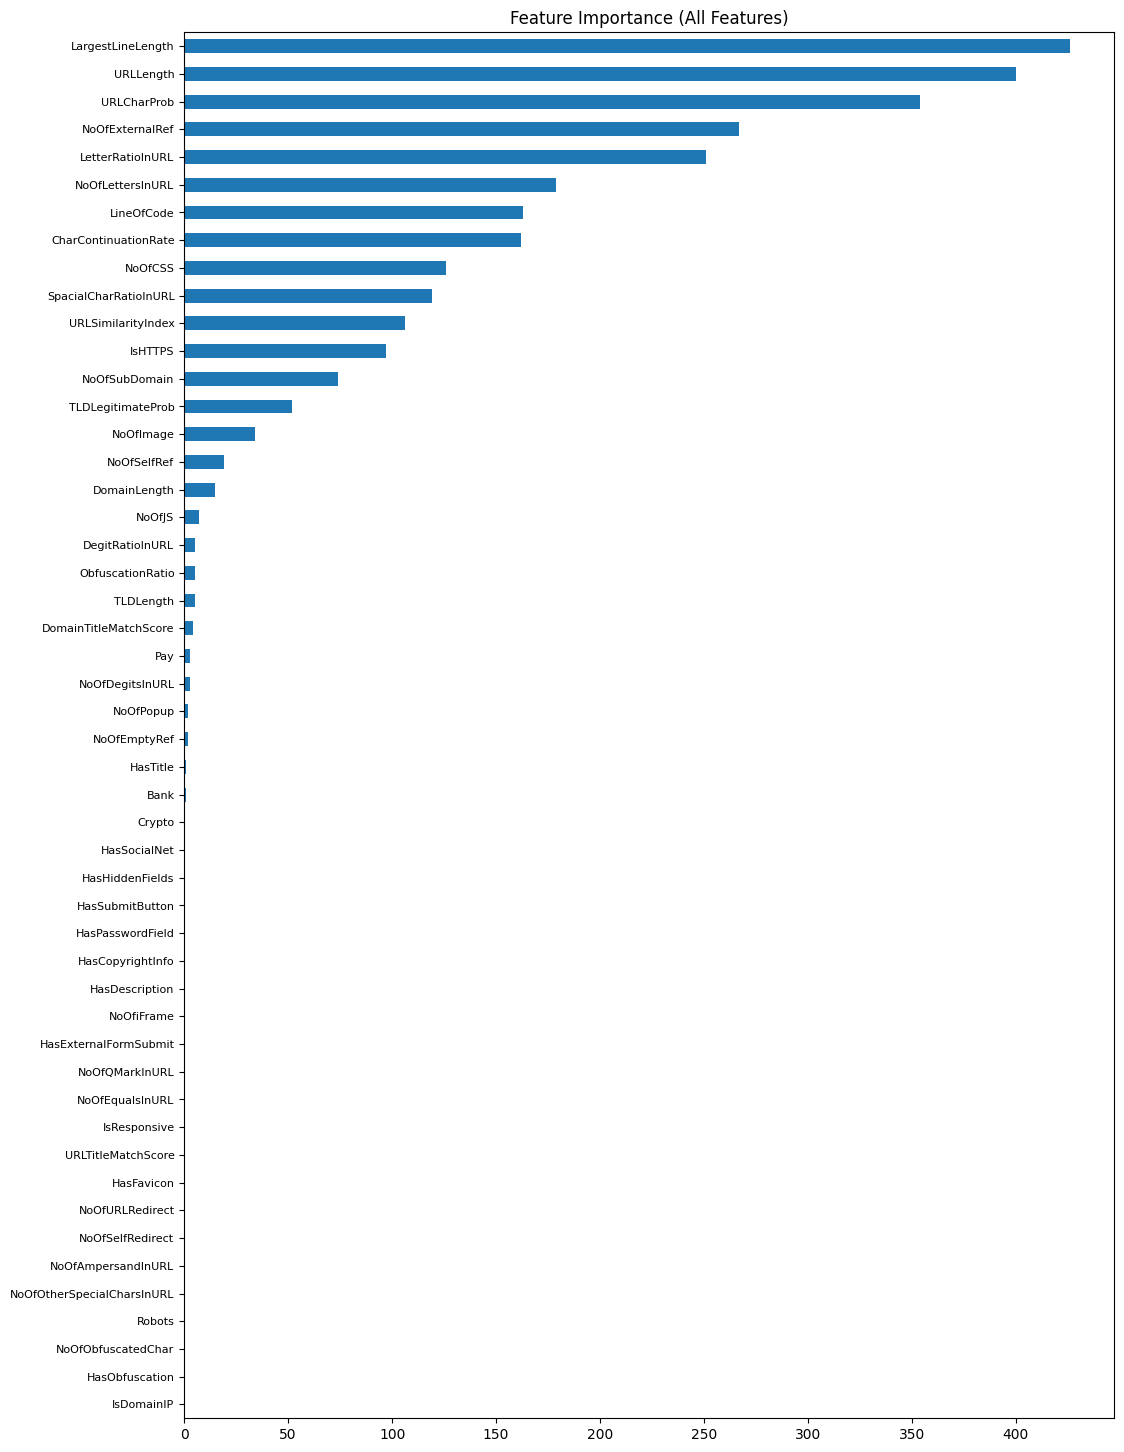

In [96]:
# see important features
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

# sort ascending (least important at top)
importance = importance.sort_values()
#print(importance)
plt.figure(figsize=(12,18))
importance.plot(kind="barh")
plt.yticks(fontsize=8)
plt.title("Feature Importance (All Features)")
plt.show()

In [95]:
df = df.drop([
    "IsDomainIP",
    "HasObfuscation",
    "NoOfObfuscatedChar",
    "Robots",
    "NoOfOtherSpecialCharsInURL",
    "NoOfAmpersandInURL",
    "NoOfSelfRedirect",
    "NoOfURLRedirect",
    "HasFavicon",
    "URLTitleMatchScore",
    "IsResponsive",
    "NoOfEqualsInURL",
    "NoOfQMarkInURL",
    "HasExternalFormSubmit",
    "NoOfiFrame",
    "HasDescription",
    "HasCopyrightInfo",
    "HasPasswordField",
    "HasSubmitButton",
    "HasHiddenFields",
    "HasSocialNet",
    "Crypto",
    "Bank",
    "HasTitle",
    "NoOfEmptyRef",
    "NoOfPopup",
    "NoOfDegitsInURL",
    "Pay",
    "DomainTitleMatchScore",
    "TLDLength",
    "ObfuscationRatio",
    "DegitRatioInURL"
], axis=1, errors="ignore")

# Standardization

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("label", axis=1)
y = df["label"]

# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Step 2: Scale
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KMeans Feature

In [126]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)

# fit only on training data
kmeans.fit(X_train_scaled)

# assign clusters
df["Cluster"] = kmeans.predict(X_scaled)

In [127]:
print(df["Cluster"].value_counts())

Cluster
1    161661
0     74134
Name: count, dtype: int64


# Final Model

In [123]:
X = df.drop("label", axis=1)
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LGBMClassifier()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, pred))

[LightGBM] [Info] Number of positive: 107815, number of negative: 80821
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010410 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3539
[LightGBM] [Info] Number of data points in the train set: 188636, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.571550 -> initscore=0.288180
[LightGBM] [Info] Start training from score 0.288180
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

# Save the file

In [125]:
df.to_csv("final_phishing_dataset.csv", index=False)